## Phase 1: Run Linear Probes on Single Datasets: LLaMA-2-7B on SVAMP (1k)

* [Done] Variations: SE -> Acc; SE -> SE; Acc -> Acc. <br>
* [Done] Across all layers for both SLT and TBG tokens. **Goal: find best layers**. <br>
* [Done] Binarization (best split via regression forest). <br>
* [Done] Save log of test metrics for visualization.
* [Done] Take some time to alter the llama codes for keeping residuals and attention outputs.
* [_Failed due to incorrect tensors_] We study effects of residual branch and mlp outputs .

In [1]:
%load_ext autoreload
%autoreload 2

import os
import pickle
import yaml
import json

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
import torch

from copy import deepcopy
import seaborn as sns

import wandb
os.chdir('/scratch-ssd/ms23jh/uncertainty/wandb-ref/run-20240506_183640-7p2kwrqp/files') # path for mistral-7b on svamp (1k)

Matplotlib created a temporary cache directory at /tmp/matplotlib-utna0psl because the default path (/scratch-ssd/oatml/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## Utility Functions

In [2]:
# Read training generated embeddings
f = open('validation_generations.pkl', 'rb')
generations = pickle.load(f)
f.close()

# Read uncertainty measures (p-true, predictive/semantic uncertainties)
g = open('uncertainty_measures.pkl', 'rb')
measures = pickle.load(g)
g.close()

In [3]:
entropy = torch.tensor(measures['uncertainty_measures']['cluster_assignment_entropy']).to(torch.float32)  # replace semantic_entropy with cluster_assignment_entropy
print(entropy.shape, entropy)

torch.Size([1000]) tensor([1.8344, 1.8344, 1.4979, 1.6434, 0.8018, 2.3026, 1.9730, 0.5004, -0.0000,
        0.3251, 0.9404, 0.3251, -0.0000, 1.8344, 1.4185, 2.3026, 0.3251, 0.6390,
        0.3251, 2.3026, -0.0000, 0.6390, 1.8867, 1.4979, -0.0000, 0.8018, 1.3592,
        -0.0000, -0.0000, 0.8018, 0.3251, 2.3026, 1.6094, 0.3251, 2.3026, 0.9404,
        2.1640, 1.5048, 2.0253, -0.0000, 0.3251, 0.6390, 2.0253, 2.1640, -0.0000,
        1.8344, -0.0000, 0.3251, 1.6957, 1.0889, -0.0000, 0.9433, 1.1683, -0.0000,
        1.8344, 0.3251, 1.0889, 2.1640, 1.2275, -0.0000, 0.6390, 2.0253, 1.4708,
        -0.0000, 0.8979, -0.0000, 1.8344, 1.4979, 1.9730, 1.9730, 0.3251, 1.0889,
        0.8018, -0.0000, 2.1640, 2.1640, 1.6434, 1.4185, 2.3026, -0.0000, 1.6957,
        0.3251, 2.0253, 1.9730, 2.3026, 2.0253, 1.9730, 1.6957, 0.6390, 1.1683,
        0.9404, 0.3251, 2.3026, 1.6957, 1.5048, 2.3026, 1.6434, 1.7481, 0.9404,
        1.1683, 0.8979, -0.0000, 0.5004, 0.8018, 0.3251, 1.0889, 1.1683, 2.1640,
    

In [4]:
# Define LR and MLP model structures (LR)
import torch
import torch.nn as nn
from torch.nn import Linear, ReLU, Dropout, BatchNorm1d, Sigmoid
from sklearn.linear_model import LogisticRegression, LinearRegression

class MLP(nn.Module):
    def __init__(self, in_dim, hid_dims, out_dim=1, dropout=0.5):
        super(MLP, self).__init__()
        layers = []
        
        if isinstance(hid_dims, int):
            layer_dims = [in_dim] + [hid_dims] * 2
        elif isinstance(hid_dims, list):
            layer_dims = [in_dim] + hid_dims
        else:
            raise ValueError("hid_dims must be either an integer or a list of integers")
        
        for i in range(len(layer_dims) - 1):
            layers.append(Linear(layer_dims[i], layer_dims[i+1]))
            layers.append(BatchNorm1d(layer_dims[i+1]))
            layers.append(ReLU())
            layers.append(Dropout(dropout))

        layers.append(Linear(layer_dims[-1], out_dim))        
        self.layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.layers(x)


class MLPClassifier(MLP):
    def __init__(self, in_dim, hid_dims, dropout):
        super().__init__(in_dim, hid_dims, out_dim=1, dropout=dropout)

    def forward(self, x):
        x = super().forward(x)
        x = torch.sigmoid(x) 
        return x

## Use Linear Probe for Predicting Semantic Entropy 

We experiment with the 'Last Input Token before Generation' first.

We train simple MLPs (4 hidden layers, 100 epochs w/ early stopping) on the token embeddings from each layer on _semantic entropy_ scores. 

In this section, we only prepare datasets for later transfer learning tasks.

In [5]:
# Hidden states:
tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['emb_last_tok_before_gen'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)

# Residual connection:
# tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['tbg_res_embeds'] 
                                    # for record in generations.values()]).squeeze(-2).to(torch.float32)

# MLP outputs:
# tok_bef_gen_dataset = torch.stack([record['most_likely_answer']['tbg_mlp_embeds'] 
#                                 for record in generations.values()]).squeeze(-2).to(torch.float32)

print(tok_bef_gen_dataset.shape)

torch.Size([1000, 33, 4096])


In [6]:
entropy = entropy.to(torch.float32)
ca_entropy = entropy.clone()
mean = ca_entropy.mean()
std = ca_entropy.std()
print(ca_entropy.min(), ca_entropy.max(), mean, std)
ca_entropy = (ca_entropy - mean) / std
print(ca_entropy.shape)

tensor(-0.) tensor(2.3026) tensor(1.1895) tensor(0.8111)
torch.Size([1000])


### Explore Token before First Generated Token (TBG)

We experment layer-by-layer.

In [7]:
tok_bef_gen_layered_datasets = tok_bef_gen_dataset.transpose(0, 1)
print(tok_bef_gen_layered_datasets.shape)

torch.Size([33, 1000, 4096])


In [8]:
# Make batched inputs and dataloaders (one for each layer)
from torch.utils.data import DataLoader, Subset, TensorDataset, ConcatDataset

from sklearn.model_selection import train_test_split

total_size = 2000  # Number of samples
batch_size = 32

def create_dataloaders(tok_bef_gen_layered_datasets, semantic_entropy, total_size, batch_size, set_seed=False, val_test_splits=[0.2, 0.1]):
    if set_seed:
        torch.manual_seed(42)
    
    indices = torch.randperm(total_size)
    test_size = int(total_size * val_test_splits[1])
    valid_size = int((total_size - test_size) * val_test_splits[0])
    train_size = total_size - test_size - valid_size

    train_indices = indices[:train_size]
    valid_indices = indices[train_size:train_size + valid_size]
    test_indices = indices[train_size + valid_size:]

    tbg_train_dataloaders = []
    tbg_valid_dataloaders = []
    tbg_test_dataloaders = []

    for i in range(tok_bef_gen_layered_datasets.shape[0]):
        dataset_i = tok_bef_gen_layered_datasets[i]
        
        tensor_dataset_i = TensorDataset(dataset_i, semantic_entropy)
        
        train_dataset_i = Subset(tensor_dataset_i, train_indices)
        valid_dataset_i = Subset(tensor_dataset_i, valid_indices)
        test_dataset_i = Subset(tensor_dataset_i, test_indices)
        
        train_dataloader_i = DataLoader(train_dataset_i, batch_size=batch_size, shuffle=True)
        valid_dataloader_i = DataLoader(valid_dataset_i, batch_size=batch_size, shuffle=False)
        test_dataloader_i = DataLoader(test_dataset_i, batch_size=batch_size, shuffle=False)
        
        tbg_train_dataloaders.append(train_dataloader_i)
        tbg_valid_dataloaders.append(valid_dataloader_i)
        tbg_test_dataloaders.append(test_dataloader_i)

    return tbg_train_dataloaders, tbg_valid_dataloaders, tbg_test_dataloaders
    
def create_Xs_and_ys(tok_bef_gen_layered_datasets, ca_entropy, total_size, val_test_splits=[0.2, 0.1]):
    # Data splitting for sklearn linear models
    X = tok_bef_gen_layered_datasets.numpy()
    y = ca_entropy.numpy()

    valid_size = val_test_splits[0]
    test_size = val_test_splits[1]

    X_trains = []
    X_vals = []
    X_tests = []
    y_trains = []
    y_vals = []
    y_tests = []

    for i in range(X.shape[0]):
        # Split data into train, validation, and test sets
        X_train_val, X_test, y_train_val, y_test = train_test_split(X[i], y, test_size=test_size, random_state=42)
        X_tests.append(X_test)
        y_tests.append(y_test)
        X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=valid_size, random_state=42) 
        X_trains.append(X_train)
        y_trains.append(y_train)
        X_vals.append(X_val)
        y_vals.append(y_val)

    return X_trains, X_vals, X_tests, y_trains, y_vals, y_tests

In [9]:
# Training and testing helper function.
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from sklearn.metrics import log_loss, roc_auc_score, mean_squared_error

# Use verbose=1 for model loss tracking.
def sklearn_train_and_evaluate(model, X_train, y_train, X_valid, y_valid, binary_cls=False, title="", silent=False):
    model.fit(X_train, y_train)
    
    # Calculate training loss and score
    if binary_cls:
        train_probs = model.predict_proba(X_train)
        train_loss = log_loss(y_train, train_probs)
    else:
        train_preds = model.predict(X_train)
        train_loss = mean_squared_error(y_train, train_preds)

    # Calculate validation loss
    valid_preds = model.predict(X_valid)
    if binary_cls:
        valid_probs = model.predict_proba(X_valid)
        valid_loss = log_loss(y_valid, valid_probs)
        val_accuracy = np.mean((valid_preds == y_valid).astype(int))
        auroc_score = roc_auc_score(y_valid, valid_probs[:,1])
        print(f"Validation Accuracy: {val_accuracy:.4f}, AUROC: {auroc_score:.4f}")
    else:
        valid_loss = mean_squared_error(y_valid, valid_preds)
        # train_score = model.score(X_train, y_train)
        # val_score = model.score(X_valid, y_valid)
        # print(f"Training R_squared: {train_score:.4f}, Validation R_squared: {val_score:.4f}")
    print(f"Training Loss: {train_loss:.4f}, Validation Loss: {valid_loss:.4f}")

def sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=False):
    test_preds = model.predict(X_test)
    if binary_cls:
        test_probs = model.predict_proba(X_test)
        test_loss = log_loss(y_test, test_probs)
    else:
        test_loss = mean_squared_error(y_test, test_preds)
        
    if binary_cls:
        test_probs = test_probs[:, 1]  # Probabilities for the positive class
        test_accuracy = np.mean((test_preds == y_test).astype(int))
        auroc_score = roc_auc_score(y_test, test_probs)
        print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return test_loss, test_accuracy, auroc_score
    else:
        test_score = model.score(X_test, y_test)
        print(f"Test Loss: {test_loss:.4f}, Test R-squared: {test_score:.4f}")
        return test_loss


def train_and_evaluate(model, train_loader, valid_loader, device, criterion=nn.MSELoss(), epochs=50, 
                       binary_cls=False, title="", silent=False, lr=0.0005):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    valid_losses = []

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0
        if binary_cls:
            total_train_correct = 0
            total_train_samples = 0
            
        for inputs, scalars in train_loader:
            inputs, scalars = inputs.to(device), scalars.to(device)
            optimizer.zero_grad()
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, scalars)
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                matches = preds == scalars
                total_train_correct += matches.int().sum().item()
                total_train_samples += scalars.size(0)
        
        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        model.eval()
        total_valid_loss = 0
        with torch.no_grad():
            for inputs, scalars in valid_loader:
                inputs, scalars = inputs.to(device), scalars.to(device)
                outputs = model(inputs).squeeze()
                loss = criterion(outputs, scalars)
                total_valid_loss += loss.item()

        avg_valid_loss = total_valid_loss / len(valid_loader)
        valid_losses.append(avg_valid_loss)

        if epoch == 0 or (epoch+1) % 10 == 0:
            if binary_cls:
                train_accuracy = total_train_correct / total_train_samples
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
            else:
                print(f"Epoch {epoch+1}/{epochs}, Training Loss: {avg_train_loss:.4f}, Validation Loss: {avg_valid_loss:.4f}")

    # Plot training and validation loss
    if not silent:
        plt.figure(figsize=(10, 5))
        plt.plot(train_losses, label='Training Loss')
        plt.plot(valid_losses, label='Validation Loss')
        plt.title(f'Training and Validation Losses for {title}')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.show()

    return None

def evaluate_on_test(model, test_loader, device, criterion=nn.MSELoss(), binary_cls=False):
    model.to(device)
    model.eval()
    total_test_loss = 0
    all_preds = []
    all_outputs = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs).squeeze()
            loss = criterion(outputs, labels)
            total_test_loss += loss.item()

            if binary_cls:
                preds = outputs > 0.5
                all_preds.extend(preds.cpu().numpy())
                all_outputs.extend(outputs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

    avg_test_loss = total_test_loss / len(test_loader)

    if binary_cls:
        test_accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
        auroc_score = roc_auc_score(all_labels, all_outputs) if len(set(all_labels)) > 1 else float('nan')
        
        print(f"Test Loss: {avg_test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}, AUROC: {auroc_score:.4f}")
        return avg_test_loss, test_accuracy, auroc_score
    else:
        print(f"Test Loss: {avg_test_loss:.4f}")
        return avg_test_loss

In [10]:
# Plot the 1-D pooled test losses
from datetime import datetime

def plot_1d_metrics(test_metrics_list, model_names, metric_name="MSE Losses", save_fig=False, use_logarithm=False):
    plt.figure(figsize=(10, 5))
    
    # Make sure that model_names array and test_metrics_list have the same length.
    if len(test_metrics_list) != len(model_names):
        raise ValueError("The length of test_metrics_list and model_names must be the same.")
    
    for test_metrics, model_name in zip(test_metrics_list, model_names):
        test_metrics = torch.tensor(test_metrics, dtype=torch.float32)
        if use_logarithm:
            test_metrics = torch.log(test_metrics + 1e-6)
        layer_indices = torch.arange(len(test_metrics)) + 1  # +1 if layer indexing starts at 1
        plt.plot(layer_indices, test_metrics, marker='o', linestyle='-', label=model_name)
    
    plt.title(f'Test {metric_name} per Layer')
    plt.xlabel('Layer_i')
    plt.ylabel(f'{metric_name}')
    plt.xticks(layer_indices)  # Assuming all models have the same number of layers
    plt.legend()
    plt.grid(True)
    formatted_time = datetime.now().strftime("%Y%m%d-%H%M%S")
    full_path = '~/Downloads/oatml/semantic_uncertainty/figures'
    full_path = os.path.expanduser(full_path)
    if save_fig:
        plt.savefig(f'{full_path}/test_{metric_name}_per_layer_for_{"_".join(model_names)}_{formatted_time}.jpg')
    plt.show()

#### Binarize Entropy and Predict with Logistic Regression

We try binarizing the entropy scores and use logistic regression as with the accuracy prediction.

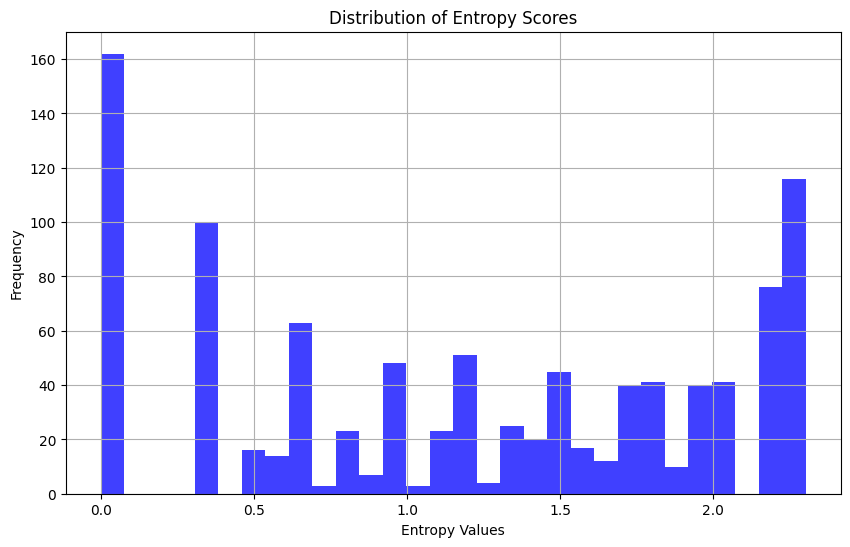

In [11]:
# Plot the entropy distribution
def plot_entropy_distribution(entropies):
    entropies_np = entropies.numpy()
    plt.figure(figsize=(10, 6))  # Set the figure size
    plt.hist(entropies_np, bins=30, alpha=0.75, color='blue')
    plt.title('Distribution of Entropy Scores')  # Title of the histogram
    plt.xlabel('Entropy Values')  # Label for the x-axis
    plt.ylabel('Frequency')  # Label for the y-axis
    plt.grid(True) 
    plt.show()

plot_entropy_distribution(entropy)

1.0931464735228855

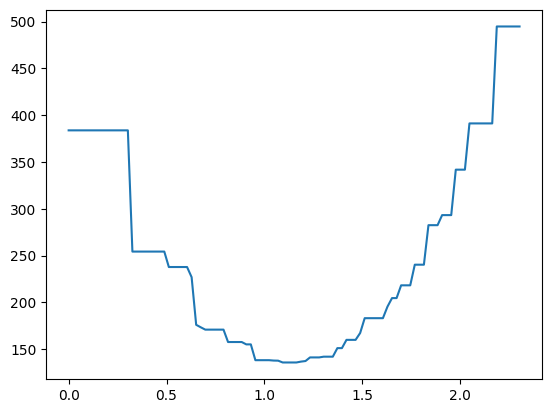

In [12]:
# Use best split approach (from Zebra notebook)
ents = entropy.numpy()
splits = np.linspace(1e-10, ents.max(), 100)
split_mses = []
for split in splits:
    low_idxs, high_idxs = ents < split, ents >= split

    low_mean = np.mean(ents[low_idxs])
    high_mean = np.mean(ents[high_idxs])

    mse = np.sum((ents[low_idxs] - low_mean)**2) + np.sum((ents[high_idxs] - high_mean)**2)
    mse = np.sum(mse)

    split_mses.append(mse)

split_mses = np.array(split_mses)

plt.plot(splits, split_mses)
splits[np.argmin(split_mses)]

In [13]:
def binarize_entropy(entropy, thres=0.0):  # 0.0 means even splits for normalized entropy scores
    """Binarize entropy scores into 0's and 1's"""
    binary_entropy = torch.full_like(entropy, -1, dtype=torch.float)
    binary_entropy[entropy < thres] = 0
    binary_entropy[entropy > thres] = 1

    return binary_entropy

bca_entropy = binarize_entropy(entropy, splits[np.argmin(split_mses)])
# bca_entropy = binarize_entropy(ca_entropy, 0.0)
print(f"Dummy accuracy: {max(torch.mean(bca_entropy).item(), 1-torch.mean(bca_entropy).item()):.4f}")

Dummy accuracy: 0.5380


In [14]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)

In [15]:
# Training with LR.
tblr_test_accs = []
tblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tblr_test_accs.append(test_acc)
    tblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5833, AUROC: 0.4879
Training Loss: 0.6894, Validation Loss: 0.6858
Test Loss: 0.6894, Test Accuracy: 0.5300, AUROC: 0.5887
Training on Dataset 2/33
Validation Accuracy: 0.6333, AUROC: 0.6433
Training Loss: 0.6584, Validation Loss: 0.6597
Test Loss: 0.6679, Test Accuracy: 0.5700, AUROC: 0.6379
Training on Dataset 3/33
Validation Accuracy: 0.6444, AUROC: 0.6629
Training Loss: 0.6346, Validation Loss: 0.6421
Test Loss: 0.6557, Test Accuracy: 0.5900, AUROC: 0.6632
Training on Dataset 4/33
Validation Accuracy: 0.6500, AUROC: 0.6959
Training Loss: 0.6119, Validation Loss: 0.6255
Test Loss: 0.6555, Test Accuracy: 0.6300, AUROC: 0.6660
Training on Dataset 5/33
Validation Accuracy: 0.6333, AUROC: 0.7060
Training Loss: 0.5931, Validation Loss: 0.6138
Test Loss: 0.6545, Test Accuracy: 0.6100, AUROC: 0.6780
Training on Dataset 6/33
Validation Accuracy: 0.6611, AUROC: 0.7457
Training Loss: 0.5613, Validation Loss: 0.5920
Test Loss: 0.6469, Test Accura

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7722, AUROC: 0.8775
Training Loss: 0.1322, Validation Loss: 0.4500
Test Loss: 0.4273, Test Accuracy: 0.8000, AUROC: 0.8984
Training on Dataset 19/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8644
Training Loss: 0.0973, Validation Loss: 0.5218
Test Loss: 0.4362, Test Accuracy: 0.8000, AUROC: 0.8832
Training on Dataset 20/33


...

Validation Accuracy: 0.7500, AUROC: 0.8615
Training Loss: 0.0491, Validation Loss: 0.5878
Test Loss: 0.4271, Test Accuracy: 0.8400, AUROC: 0.9113
Training on Dataset 24/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8583
Training Loss: 0.0456, Validation Loss: 0.6166
Test Loss: 0.4227, Test Accuracy: 0.8600, AUROC: 0.9101
Training on Dataset 25/33
Validation Accuracy: 0.7444, AUROC: 0.8526
Training Loss: 0.0409, Validation Loss: 0.6508
Test Loss: 0.4476, Test Accuracy: 0.8600, AUROC: 0.9012
Training on Dataset 26/33
Validation Accuracy: 0.7611, AUROC: 0.8508
Training Loss: 0.0364, Validation Loss: 0.6622
Test Loss: 0.4691, Test Accuracy: 0.8500, AUROC: 0.8948
Training on Dataset 27/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7722, AUROC: 0.8700
Training Loss: 0.0281, Validation Loss: 0.6571
Test Loss: 0.3644, Test Accuracy: 0.8500, AUROC: 0.9297
Training on Dataset 28/33
Validation Accuracy: 0.7611, AUROC: 0.8709
Training Loss: 0.0250, Validation Loss: 0.6449
Test Loss: 0.3538, Test Accuracy: 0.8400, AUROC: 0.9342
Training on Dataset 29/33
Validation Accuracy: 0.7667, AUROC: 0.8875
Training Loss: 0.0221, Validation Loss: 0.5858
Test Loss: 0.3699, Test Accuracy: 0.8200, AUROC: 0.9338
Training on Dataset 30/33
Validation Accuracy: 0.8000, AUROC: 0.8935
Training Loss: 0.0175, Validation Loss: 0.5993
Test Loss: 0.3511, Test Accuracy: 0.8400, AUROC: 0.9406
Training on Dataset 31/33
Validation Accuracy: 0.8222, AUROC: 0.9112
Training Loss: 0.0117, Validation Loss: 0.5482
Test Loss: 0.3185, Test Accuracy: 0.8600, AUROC: 0.9522
Training on Dataset 32/33
Validation Accuracy: 0.8333, AUROC: 0.9180
Training Loss: 0.0102, Validation Loss: 0.5348
Test Loss: 0.3310, Test Accuracy: 0.8700, AUROC: 0

In [16]:
print(f"LR on TBG embeddings and b-SE: best AUROC {max(tblr_test_aucs):.4f} at layer {np.argmax(tblr_test_aucs)+1}")

LR on TBG embeddings and b-SE: best AUROC 0.9522 at layer 31


### Explore Second Last generated Token (SLT)


In [17]:
sec_last_tok_dataset = torch.stack([record['most_likely_answer']['emb_tok_before_eos'] 
                                   for record in generations.values()]).squeeze(-2).to(torch.float32)
print(sec_last_tok_dataset.shape)

torch.Size([1000, 33, 4096])


In [18]:
sec_last_tok_dataset.transpose(0, 1).shape

torch.Size([33, 1000, 4096])

In [19]:
slt_layered_datasets = sec_last_tok_dataset.transpose(0, 1)
print(slt_layered_datasets.shape, slt_layered_datasets.dtype)

torch.Size([33, 1000, 4096]) torch.float32


In [20]:
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)

In [21]:
# Training with LR.
sblr_test_accs = []
sblr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sblr_test_accs.append(test_acc)
    sblr_test_aucs.append(test_auc)

Training on Dataset 1/33
Validation Accuracy: 0.5833, AUROC: 0.5000
Training Loss: 0.6916, Validation Loss: 0.6854
Test Loss: 0.6914, Test Accuracy: 0.5300, AUROC: 0.5000
Training on Dataset 2/33
Validation Accuracy: 0.5833, AUROC: 0.4808
Training Loss: 0.6916, Validation Loss: 0.6854
Test Loss: 0.6914, Test Accuracy: 0.5300, AUROC: 0.5713
Training on Dataset 3/33
Validation Accuracy: 0.5833, AUROC: 0.5957
Training Loss: 0.6886, Validation Loss: 0.6833
Test Loss: 0.6887, Test Accuracy: 0.5300, AUROC: 0.6182
Training on Dataset 4/33
Validation Accuracy: 0.6167, AUROC: 0.6302
Training Loss: 0.6836, Validation Loss: 0.6791
Test Loss: 0.6843, Test Accuracy: 0.5600, AUROC: 0.6447
Training on Dataset 5/33
Validation Accuracy: 0.6833, AUROC: 0.6880
Training Loss: 0.6707, Validation Loss: 0.6665
Test Loss: 0.6725, Test Accuracy: 0.6600, AUROC: 0.6877
Training on Dataset 6/33
Validation Accuracy: 0.6722, AUROC: 0.7098
Training Loss: 0.6566, Validation Loss: 0.6523
Test Loss: 0.6605, Test Accura

In [22]:
print(f"LR on SLT embeddings and b-SE: best AUROC {max(sblr_test_aucs):.4f} at layer {np.argmax(sblr_test_aucs)+1}")

LR on SLT embeddings and b-SE: best AUROC 0.9474 at layer 24


## Use Linear Probe for Predicting Correctness of Generated Answers (or Accuracy)

It would be interesting to see how linear probes perform at predicting accuracy obtained from using semantic entropy at selecting the most probable answer (true or false), as indicated in the `compute_uncertainty_measures.py` (_# For the semantic uncertainties, we can also change the prediction, by first selecting the semantic cluster with the highest probability, and then selecting the generation with the highest probability within that cluster._)

We will use logistic regression for this task, as for the binarized entropy prediction task.

### Token Before first Generation (TBG)

In [23]:
accuracies = torch.tensor([record['most_likely_answer']['accuracy'] for record in generations.values()])
print(accuracies.shape, accuracies[:10])  # "Accuracies" are binary. Classification task.

torch.Size([1000]) tensor([0., 0., 0., 1., 1., 0., 0., 0., 1., 1.])


In [24]:
# Prepare X's and y's for sklearn LR model.
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, accuracies, total_size)

In [25]:
# Dummy accuracy:
print(f"Dummy accuracy: {max(np.mean(y_tests), 1-np.mean(y_tests)):.4f}")

Dummy accuracy: 0.5700


In [26]:
# Training Loops (LR)
talr_test_accs = []
talr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    talr_test_accs.append(test_acc)
    talr_test_aucs.append(test_auc)

Training on TBG-Acc Dataset 1/33
Validation Accuracy: 0.4889, AUROC: 0.4936
Training Loss: 0.6870, Validation Loss: 0.6954
Test Loss: 0.6844, Test Accuracy: 0.5700, AUROC: 0.5571
Training on TBG-Acc Dataset 2/33
Validation Accuracy: 0.6667, AUROC: 0.7002
Training Loss: 0.6569, Validation Loss: 0.6599
Test Loss: 0.6618, Test Accuracy: 0.6600, AUROC: 0.6463
Training on TBG-Acc Dataset 3/33
Validation Accuracy: 0.6556, AUROC: 0.7044
Training Loss: 0.6306, Validation Loss: 0.6429
Test Loss: 0.6439, Test Accuracy: 0.6700, AUROC: 0.6520
Training on TBG-Acc Dataset 4/33
Validation Accuracy: 0.6611, AUROC: 0.7158
Training Loss: 0.6019, Validation Loss: 0.6270
Test Loss: 0.6420, Test Accuracy: 0.6300, AUROC: 0.6805
Training on TBG-Acc Dataset 5/33
Validation Accuracy: 0.6389, AUROC: 0.7074
Training Loss: 0.5809, Validation Loss: 0.6233
Test Loss: 0.6442, Test Accuracy: 0.6300, AUROC: 0.6569
Training on TBG-Acc Dataset 6/33
Validation Accuracy: 0.6667, AUROC: 0.7334
Training Loss: 0.5500, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.8000, AUROC: 0.8514
Training Loss: 0.1518, Validation Loss: 0.4936
Test Loss: 0.4842, Test Accuracy: 0.7700, AUROC: 0.8515
Training on TBG-Acc Dataset 19/33
Validation Accuracy: 0.7556, AUROC: 0.8402
Training Loss: 0.1164, Validation Loss: 0.5451
Test Loss: 0.5332, Test Accuracy: 0.7500, AUROC: 0.8425
Training on TBG-Acc Dataset 20/33
Validation Accuracy: 0.7889, AUROC: 0.8402
Training Loss: 0.1044, Validation Loss: 0.5587
Test Loss: 0.5277, Test Accuracy: 0.7500, AUROC: 0.8499
Training on TBG-Acc Dataset 21/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7333, AUROC: 0.8215
Training Loss: 0.0789, Validation Loss: 0.6423
Test Loss: 0.5960, Test Accuracy: 0.7600, AUROC: 0.8335
Training on TBG-Acc Dataset 22/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7389, AUROC: 0.8093
Training Loss: 0.0658, Validation Loss: 0.6881
Test Loss: 0.6200, Test Accuracy: 0.7600, AUROC: 0.8250
Training on TBG-Acc Dataset 23/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7556, AUROC: 0.8047
Training Loss: 0.0579, Validation Loss: 0.7176
Test Loss: 0.6265, Test Accuracy: 0.7300, AUROC: 0.8344
Training on TBG-Acc Dataset 24/33
Validation Accuracy: 0.7389, AUROC: 0.8063
Training Loss: 0.0523, Validation Loss: 0.7201
Test Loss: 0.6411, Test Accuracy: 0.7200, AUROC: 0.8270
Training on TBG-Acc Dataset 25/33
Validation Accuracy: 0.7389, AUROC: 0.8030
Training Loss: 0.0478, Validation Loss: 0.7390
Test Loss: 0.6735, Test Accuracy: 0.7400, AUROC: 0.8188
Training on TBG-Acc Dataset 26/33
Validation Accuracy: 0.7444, AUROC: 0.8055
Training Loss: 0.0429, Validation Loss: 0.7475
Test Loss: 0.6661, Test Accuracy: 0.7300, AUROC: 0.8266
Training on TBG-Acc Dataset 27/33
Validation Accuracy: 0.7500, AUROC: 0.8124
Training Loss: 0.0335, Validation Loss: 0.7734
Test Loss: 0.5693, Test Accuracy: 0.7500, AUROC: 0.8739
Training on TBG-Acc Dataset 28/33
Validation Accuracy: 0.7611, AUROC: 0.8226
Training Loss: 0.0306, Validation Loss: 0.7493
Test Loss:

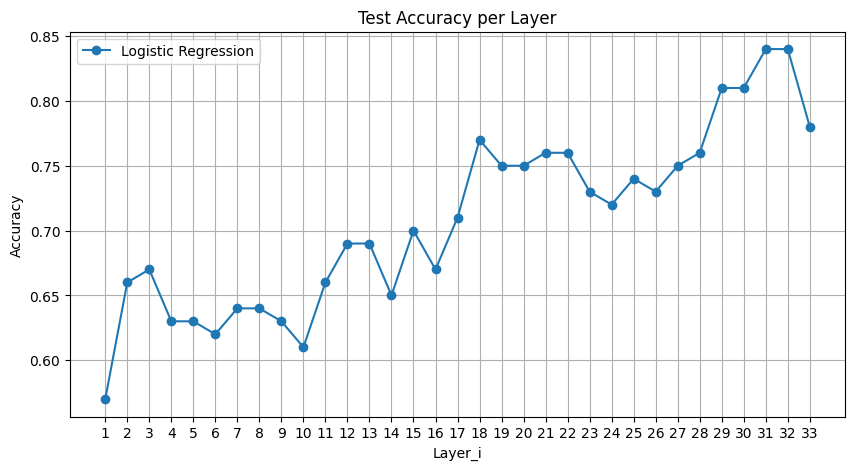

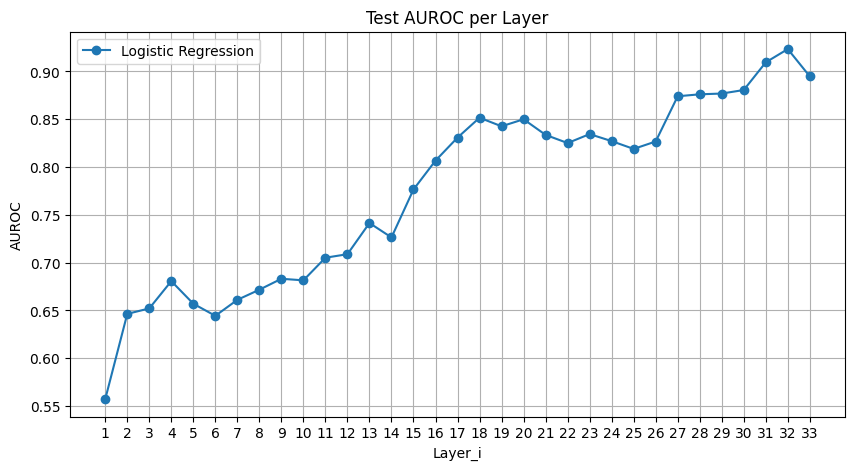

In [27]:
plot_1d_metrics([talr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([talr_test_aucs], ['Logistic Regression'], 'AUROC')

In [28]:
print(f"LR on TBG embeddings and Accuracy: best AUROC {max(talr_test_aucs):.4f} at layer {np.argmax(talr_test_aucs)+1}")

LR on TBG embeddings and Accuracy: best AUROC 0.9233 at layer 32


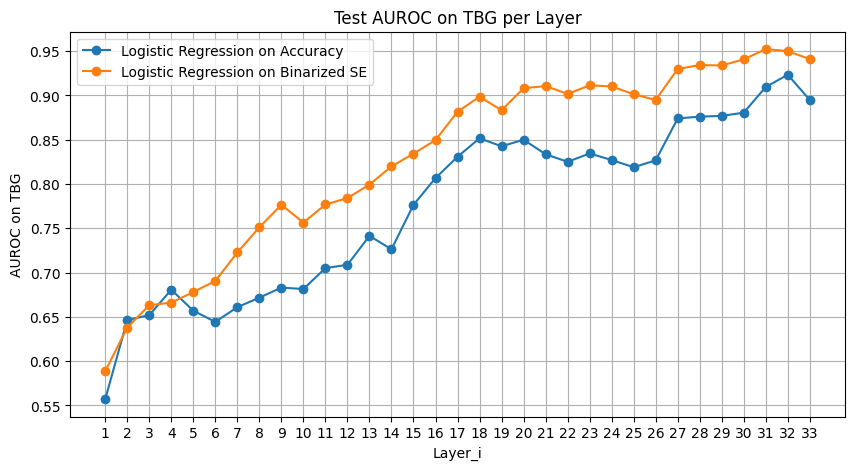

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.9233 at 32 layer
TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.9522 at 31 layer


In [29]:
plot_1d_metrics([talr_test_aucs, tblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(tblr_test_aucs):.4f} at {np.argmax(tblr_test_aucs)+1} layer")

In [30]:
# Data for SLT embeddings
X_trains, X_vals, X_tests, y_trains, y_vals, y_tests = create_Xs_and_ys(slt_layered_datasets, accuracies, total_size)

In [31]:
# Training with LR.
salr_test_accs = []
salr_test_aucs = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT-Acc Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT-Acc Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    salr_test_accs.append(test_acc)
    salr_test_aucs.append(test_auc)

Training on SLT-Acc Dataset 1/33
Validation Accuracy: 0.4889, AUROC: 0.5000
Training Loss: 0.6919, Validation Loss: 0.6955
Test Loss: 0.6874, Test Accuracy: 0.5700, AUROC: 0.5000
Training on SLT-Acc Dataset 2/33
Validation Accuracy: 0.4889, AUROC: 0.6374
Training Loss: 0.6919, Validation Loss: 0.6955
Test Loss: 0.6874, Test Accuracy: 0.5700, AUROC: 0.5418
Training on SLT-Acc Dataset 3/33
Validation Accuracy: 0.4889, AUROC: 0.6449
Training Loss: 0.6903, Validation Loss: 0.6935
Test Loss: 0.6850, Test Accuracy: 0.5700, AUROC: 0.6842
Training on SLT-Acc Dataset 4/33
Validation Accuracy: 0.4944, AUROC: 0.6989
Training Loss: 0.6870, Validation Loss: 0.6891
Test Loss: 0.6823, Test Accuracy: 0.5700, AUROC: 0.6532
Training on SLT-Acc Dataset 5/33
Validation Accuracy: 0.5722, AUROC: 0.7294
Training Loss: 0.6779, Validation Loss: 0.6760
Test Loss: 0.6743, Test Accuracy: 0.6100, AUROC: 0.6471
Training on SLT-Acc Dataset 6/33
Validation Accuracy: 0.6333, AUROC: 0.7380
Training Loss: 0.6658, Valida

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


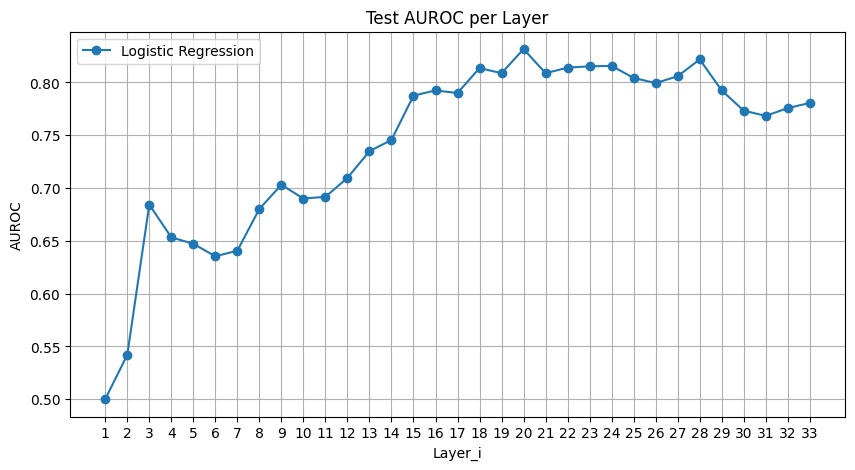

In [32]:
# plot_1d_metrics([salr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([salr_test_aucs], ['Logistic Regression'], 'AUROC')

In [33]:
print(f"LR on SLT embeddings and Accuracy: best AUROC {max(salr_test_aucs):.4f} at layer {np.argmax(salr_test_aucs)+1}")

LR on SLT embeddings and Accuracy: best AUROC 0.8315 at layer 20


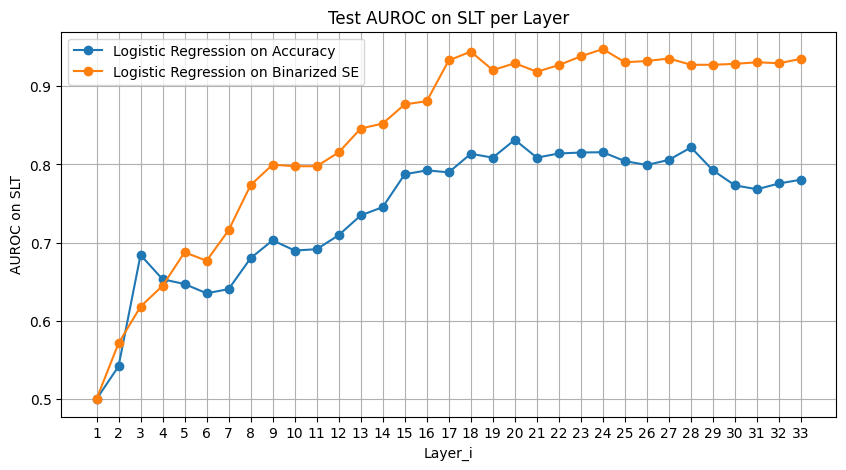

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8315 at 20 layer
SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: 0.9474 at 24 layer


In [34]:
plot_1d_metrics([salr_test_aucs, sblr_test_aucs], ['Logistic Regression on Accuracy', 'Logistic Regression on Binarized SE'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Binary SE: {max(sblr_test_aucs):.4f} at {np.argmax(sblr_test_aucs)+1} layer")

## Use Classifier for Binary SE for Predicting LLM Accuracy

We want to show that models trained on binary SE are more generalizable to new datasets when predicting their generation correctness.

In [35]:
# Test with accuracy test set (with the same random seed to ensure no data leakage)
# We should reverse the accuracy due to negative R.
r_accuracies = 1 - accuracies

X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(tok_bef_gen_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(tok_bef_gen_layered_datasets, r_accuracies, total_size)

In [36]:
# Training Loops (LR)
tablr_test_accs = []
tablr_test_aucs = []
tablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on TBG Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on TBG Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    tablr_test_accs.append(test_acc)
    tablr_test_aucs.append(test_auc)
    tablr_trained_models.append(model)

Training on TBG Dataset 1/33
Validation Accuracy: 0.5833, AUROC: 0.4879
Training Loss: 0.6894, Validation Loss: 0.6858
Test Loss: 0.7008, Test Accuracy: 0.4300, AUROC: 0.5800
Training on TBG Dataset 2/33
Validation Accuracy: 0.6333, AUROC: 0.6433
Training Loss: 0.6584, Validation Loss: 0.6597
Test Loss: 0.6757, Test Accuracy: 0.5500, AUROC: 0.6299
Training on TBG Dataset 3/33
Validation Accuracy: 0.6444, AUROC: 0.6629
Training Loss: 0.6346, Validation Loss: 0.6421
Test Loss: 0.6618, Test Accuracy: 0.5900, AUROC: 0.6438
Training on TBG Dataset 4/33
Validation Accuracy: 0.6500, AUROC: 0.6959
Training Loss: 0.6119, Validation Loss: 0.6255
Test Loss: 0.6604, Test Accuracy: 0.5900, AUROC: 0.6348
Training on TBG Dataset 5/33
Validation Accuracy: 0.6333, AUROC: 0.7060
Training Loss: 0.5931, Validation Loss: 0.6138
Test Loss: 0.6605, Test Accuracy: 0.5900, AUROC: 0.6426
Training on TBG Dataset 6/33
Validation Accuracy: 0.6611, AUROC: 0.7457
Training Loss: 0.5613, Validation Loss: 0.5920
Test L

/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7722, AUROC: 0.8775
Training Loss: 0.1322, Validation Loss: 0.4500
Test Loss: 0.5887, Test Accuracy: 0.7200, AUROC: 0.8503
Training on TBG Dataset 19/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8644
Training Loss: 0.0973, Validation Loss: 0.5218
Test Loss: 0.6122, Test Accuracy: 0.7800, AUROC: 0.8315
Training on TBG Dataset 20/33


...

Validation Accuracy: 0.7500, AUROC: 0.8615
Training Loss: 0.0491, Validation Loss: 0.5878
Test Loss: 0.6045, Test Accuracy: 0.7600, AUROC: 0.8862
Training on TBG Dataset 24/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7667, AUROC: 0.8583
Training Loss: 0.0456, Validation Loss: 0.6166
Test Loss: 0.5845, Test Accuracy: 0.8000, AUROC: 0.8874
Training on TBG Dataset 25/33
Validation Accuracy: 0.7444, AUROC: 0.8526
Training Loss: 0.0409, Validation Loss: 0.6508
Test Loss: 0.5859, Test Accuracy: 0.8000, AUROC: 0.8870
Training on TBG Dataset 26/33
Validation Accuracy: 0.7611, AUROC: 0.8508
Training Loss: 0.0364, Validation Loss: 0.6622
Test Loss: 0.6028, Test Accuracy: 0.7900, AUROC: 0.8756
Training on TBG Dataset 27/33


/scratch-ssd/ms23jh/conda_envs/llm/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Validation Accuracy: 0.7722, AUROC: 0.8700
Training Loss: 0.0281, Validation Loss: 0.6571
Test Loss: 0.6096, Test Accuracy: 0.7500, AUROC: 0.8935
Training on TBG Dataset 28/33
Validation Accuracy: 0.7611, AUROC: 0.8709
Training Loss: 0.0250, Validation Loss: 0.6449
Test Loss: 0.6182, Test Accuracy: 0.7600, AUROC: 0.8939
Training on TBG Dataset 29/33
Validation Accuracy: 0.7667, AUROC: 0.8875
Training Loss: 0.0221, Validation Loss: 0.5858
Test Loss: 0.6080, Test Accuracy: 0.7600, AUROC: 0.9033
Training on TBG Dataset 30/33
Validation Accuracy: 0.8000, AUROC: 0.8935
Training Loss: 0.0175, Validation Loss: 0.5993
Test Loss: 0.6818, Test Accuracy: 0.7800, AUROC: 0.8902
Training on TBG Dataset 31/33
Validation Accuracy: 0.8222, AUROC: 0.9112
Training Loss: 0.0117, Validation Loss: 0.5482
Test Loss: 0.7661, Test Accuracy: 0.7600, AUROC: 0.8907
Training on TBG Dataset 32/33
Validation Accuracy: 0.8333, AUROC: 0.9180
Training Loss: 0.0102, Validation Loss: 0.5348
Test Loss: 0.7970, Test Accura

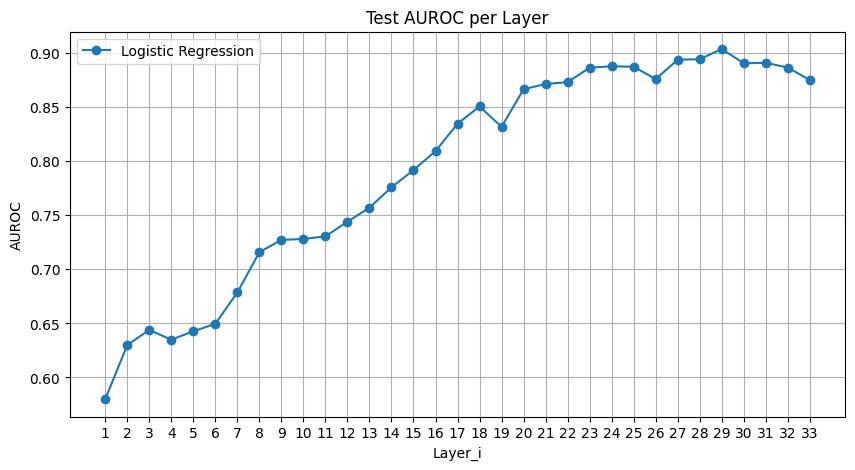

In [37]:
# plot_1d_metrics([tablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([tablr_test_aucs], ['Logistic Regression'], 'AUROC')

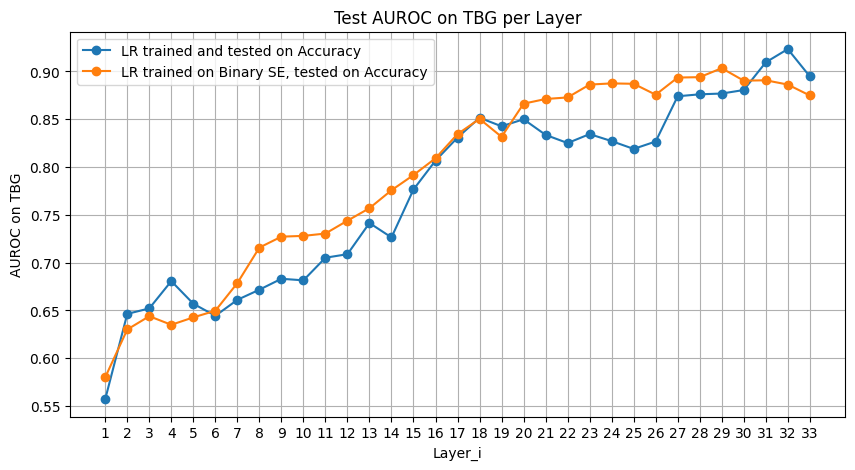

TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.9233 at 32 layer
TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.9033 at 29 layer


In [38]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([talr_test_aucs, tablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on TBG')
print(f"TBG: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(talr_test_aucs):.4f} at {np.argmax(talr_test_aucs)+1} layer")
print(f"TBG: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(tablr_test_aucs):.4f} at {np.argmax(tablr_test_aucs)+1} layer")

Now we test on SLT embeddings.

In [39]:
X_trains, X_vals, _, y_trains, y_vals, _ = create_Xs_and_ys(slt_layered_datasets, bca_entropy, total_size)
_, _, X_tests, _, _, y_tests = create_Xs_and_ys(slt_layered_datasets, r_accuracies, total_size)

In [40]:
# Training Loops (LR)
sablr_test_accs = []
sablr_test_aucs = []
sablr_trained_models = []

for i, (X_train, X_val, X_test, y_train, y_val, y_test) in enumerate(zip(X_trains, X_vals, X_tests, y_trains, y_vals, y_tests)):
    print(f"Training on SLT Dataset {i+1}/{len(X_trains)}")
    model = LogisticRegression()
    sklearn_train_and_evaluate(model, X_train, y_train, X_val, y_val, binary_cls=True, title=f"Logistic Regression on SLT Dataset {i+1}")
    test_loss, test_acc, test_auc = sklearn_evaluate_on_test(model, X_test, y_test, binary_cls=True)
    sablr_test_accs.append(test_acc)
    sablr_test_aucs.append(test_auc)
    sablr_trained_models.append(model)

Training on SLT Dataset 1/33
Validation Accuracy: 0.5833, AUROC: 0.5000
Training Loss: 0.6916, Validation Loss: 0.6854
Test Loss: 0.7025, Test Accuracy: 0.4300, AUROC: 0.5000
Training on SLT Dataset 2/33
Validation Accuracy: 0.5833, AUROC: 0.4808
Training Loss: 0.6916, Validation Loss: 0.6854
Test Loss: 0.7025, Test Accuracy: 0.4300, AUROC: 0.5198
Training on SLT Dataset 3/33
Validation Accuracy: 0.5833, AUROC: 0.5957
Training Loss: 0.6886, Validation Loss: 0.6833
Test Loss: 0.6987, Test Accuracy: 0.4300, AUROC: 0.6520
Training on SLT Dataset 4/33
Validation Accuracy: 0.6167, AUROC: 0.6302
Training Loss: 0.6836, Validation Loss: 0.6791
Test Loss: 0.6946, Test Accuracy: 0.4400, AUROC: 0.6532
Training on SLT Dataset 5/33
Validation Accuracy: 0.6833, AUROC: 0.6880
Training Loss: 0.6707, Validation Loss: 0.6665
Test Loss: 0.6837, Test Accuracy: 0.6000, AUROC: 0.6732
Training on SLT Dataset 6/33
Validation Accuracy: 0.6722, AUROC: 0.7098
Training Loss: 0.6566, Validation Loss: 0.6523
Test L

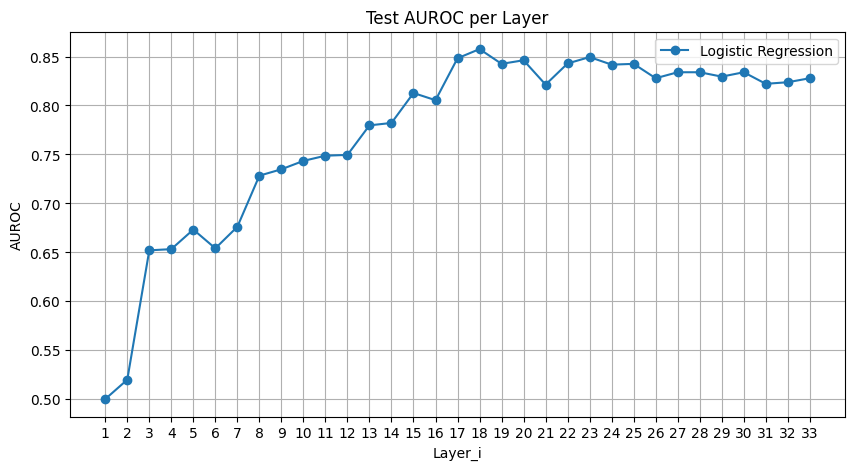

In [41]:
# plot_1d_metrics([sablr_test_accs], ['Logistic Regression'], 'Accuracy')
plot_1d_metrics([sablr_test_aucs], ['Logistic Regression'], 'AUROC')

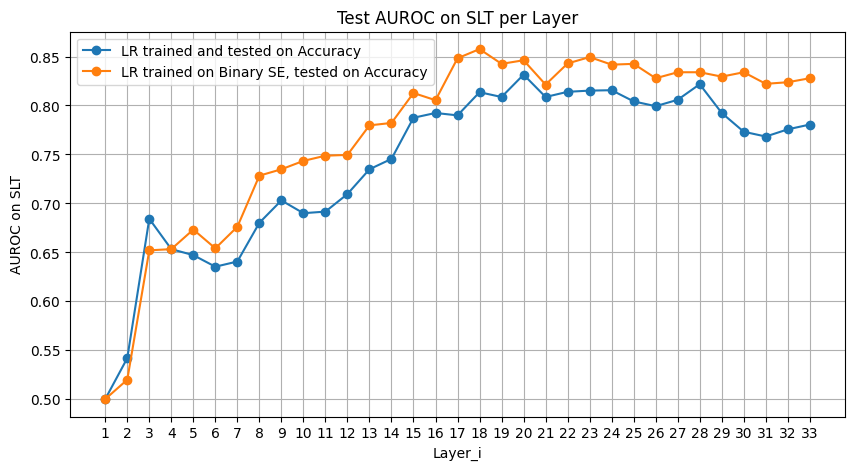

SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: 0.8315 at 20 layer
SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: 0.8576 at 18 layer


In [42]:
# Max AUROC achieved by 'transfer learning' compared to normal training
plot_1d_metrics([salr_test_aucs, sablr_test_aucs], ['LR trained and tested on Accuracy', 'LR trained on Binary SE, tested on Accuracy'], 'AUROC on SLT')
print(f"SLT: max AUROC for LR trained on Accuracy, tested on Accuracy: {max(salr_test_aucs):.4f} at {np.argmax(salr_test_aucs)+1} layer")
print(f"SLT: max AUROC for LR trained on Binary SE, tested on Accuracy: {max(sablr_test_aucs):.4f} at {np.argmax(sablr_test_aucs)+1} layer")